<a href="https://colab.research.google.com/github/JasLaras/passagemath-workspace/blob/main/shortest_path_comparisons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Comparison of Combinatorial and Optimization Methods for Graph Problems**

***Goal:***

Compare combinatorial shortest-path algorithms (Dijkstra, Bellman-Ford) with optimization-based methods (Linear Programming).

***Focus:***
*   runtime
*   scalability
*   graph structure sensitivity






In [1]:
!pip install passagemath-polyhedra

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.2/540.2 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.4/18.4 MB 42.3 MB/s eta 0:00:00


In [2]:
from sage.numerical.mip import MixedIntegerLinearProgram

import heapq
import time
import networkx as nx
import matplotlib.pyplot as plt

We consider the single-source shortest path problem on a weighted directed graph G = (V,E),

where each edge \(u,v) ∈ E has weight w(u,v) ≥ 0.

The goal is to compute:

$$
\mathrm{dist}(s, v) = \min_{P: s \to v} \sum_{(u, v) \in P} w(u, v)
$$

In [3]:
# tiny weighted graph as adjacency list

G = {
    0: [(1, 1), (2, 4)],
    1: [(2, 2), (3, 6)],
    2: [(3, 3)],
    3: []
}

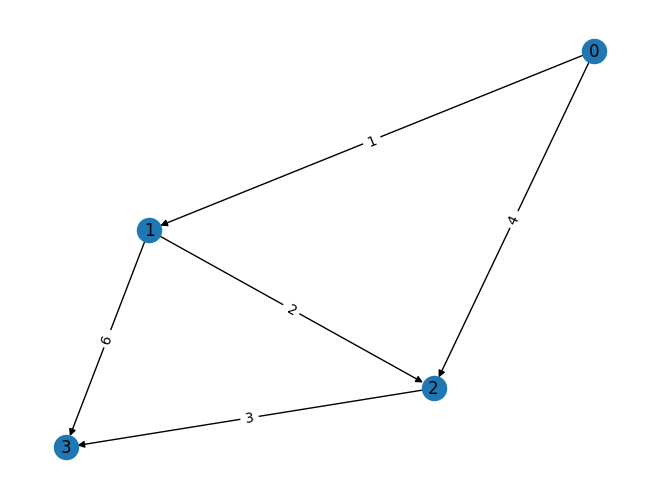

In [4]:
DG = nx.DiGraph()

for u in G:
    for v, w in G[u]:
        DG.add_edge(u, v, weight=w)

pos = nx.spring_layout(DG)

nx.draw(DG, pos, with_labels=True)
nx.draw_networkx_edge_labels(DG, pos, edge_labels=nx.get_edge_attributes(DG, 'weight'))

plt.show()

### Dijkstra’s Algorithm

Dijkstra maintains a set of visited nodes and iteratively selects the node with minimum tentative distance.

Update rule:
$$
d(v) = min(d(v),d(u) + w(u,v))
$$

Time complexity:
$$
O((|V|+|E|)log|V|)
$$

Key idea: greedy selection of locally optimal edges leads to global optimality (only valid for **nonnegative weights**).


In [5]:
def run_dijkstra(G, start=0, target=3):

    dist = {node: float('inf') for node in G}
    dist[start] = 0

    pq = [(0, start)]

    while pq:
        d, u = heapq.heappop(pq)

        if u == target:
            return d

        for v, w in G[u]:
            if dist[v] > d + w:
                dist[v] = d + w
                heapq.heappush(pq, (dist[v], v))

    return dist[target]

### Bellman–Ford Algorithm

Bellman–Ford repeatedly relaxes **all edges**:

$$
d^{(k)}(v) = \min(d^{(k-1)}(v),\ d^{(k-1)}(u) + w(u,v))
$$

After at most |V|-1 iterations, all shortest paths are found.

Time complexity:
$$
O(|V||E|)
$$

Key idea: propagates improvements iteratively across the graph and can handle negative weights.

In [6]:
def run_bellman_ford(G, start=0):

    dist = {node: float('inf') for node in G}
    dist[start] = 0

    edges = [(u, v, w) for u in G for v, w in G[u]]

    n = len(G)

    for _ in range(n - 1):
        for u, v, w in edges:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w

    return dist

### Linear Programming Formulation (Optimization Approach)

Shortest path can be formulated as a linear program:

$$
\min \sum_{(u,v)\in E} w(u,v)x_{uv}
$$

subject to flow constraints:

- Flow conservation:
$$
\sum_{(u,v)\in E} x_{uv} - \sum_{(v,u)\in E} x_{vu} =
\begin{cases}
1 & \text{if } v = s \\
-1 & \text{if } v = t \\
0 & \text{otherwise}
\end{cases}
$$

- Capacity constraints:
$$
x_{uv} \ge 0
$$

Time complexity depends on the LP solver, but with significantly higher constants in practice.

In [7]:
def run_lp():

    p = MixedIntegerLinearProgram(maximization=False)
    x = p.new_variable(nonnegative=True)

    edges = [
        (0,1,1),
        (0,2,4),
        (1,2,2),
        (1,3,6),
        (2,3,3)
    ]

    p.set_objective(sum(w * x[(u,v)] for u,v,w in edges))

    # flow constraints
    p.add_constraint(x[(0,1)] + x[(0,2)] == 1)
    p.add_constraint(x[(0,1)] - x[(1,2)] - x[(1,3)] == 0)
    p.add_constraint(x[(0,2)] + x[(1,2)] - x[(2,3)] == 0)
    p.add_constraint(x[(1,3)] + x[(2,3)] == 1)

    p.solve()

    return p.get_objective_value()

### Summary of Methods

- Dijkstra: **greedy** combinatorial optimization  
- Bellman–Ford: **dynamic** relaxation process  
- LP: global constraint optimization formulation

In [8]:
def time_function(func, *args):

    start = time.time()
    result = func(*args)
    end = time.time()

    return result, end - start

In [9]:
dijkstra_result, t_dijkstra = time_function(run_dijkstra, G)
bf_result, t_bf = time_function(run_bellman_ford, G)
lp_result, t_lp = time_function(run_lp)

print("Dijkstra shortest path:", dijkstra_result)
print("Bellman-Ford distances:", bf_result)
print("LP cost:", lp_result)

Dijkstra shortest path: 6
Bellman-Ford distances: {0: 0, 1: 1, 2: 3, 3: 6}
LP cost: 6.0


In [10]:
print("\n--- Runtime Comparison ---")
print("Dijkstra:", t_dijkstra)
print("Bellman-Ford:", t_bf)
print("LP:", t_lp)


--- Runtime Comparison ---
Dijkstra: 2.002716064453125e-05
Bellman-Ford: 1.0251998901367188e-05
LP: 2.9688398838043213


### Runtime Comparison

- Dijkstra: **fastest** (greedy structure exploitation)
- Bellman–Ford: **slightly slower** due to repeated edge relaxation
- LP: **significantly slower** due to general-purpose optimization overhead

### Key Insight

Although all methods solve the same shortest path problem, their **efficiency differs** because they exploit different mathematical structures:

- Combinatorial algorithms use graph-specific structure
- LP formulation encodes the problem as a general optimization system

As a result, **LP provides flexibility and generality**, but at the cost of computational efficiency.